In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch


In [30]:
# Load extrinsics
right = np.load('../interactive_world_sim/real_world/aloha_extrinsics/right_base_pose_in_world.npy')
left  = np.load('../interactive_world_sim/real_world/aloha_extrinsics/left_base_pose_in_world.npy')


In [31]:
right

array([[ 0.  ,  1.  ,  0.  ,  0.11],
       [-1.  ,  0.  ,  0.  ,  0.42],
       [ 0.  ,  0.  ,  1.  ,  0.02],
       [ 0.  ,  0.  ,  0.  ,  1.  ]])

In [32]:
left

array([[ 0.  , -1.  ,  0.  ,  0.11],
       [ 1.  ,  0.  ,  0.  , -0.64],
       [ 0.  ,  0.  ,  1.  ,  0.02],
       [ 0.  ,  0.  ,  0.  ,  1.  ]])

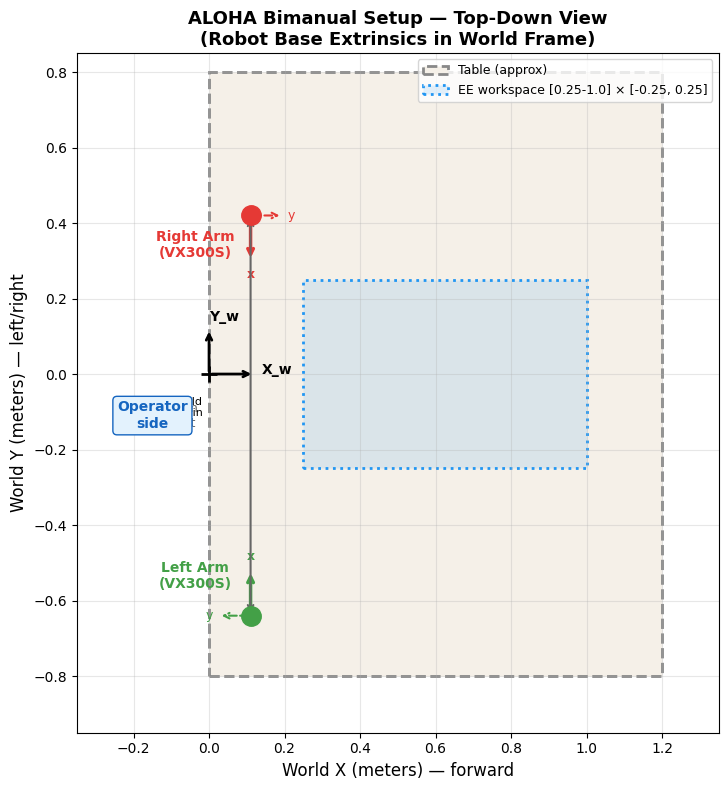

In [33]:

# We'll plot a top-down view (X-Y plane in world frame)
# World frame: X = forward (away from operator), Y = left-right

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# --- Draw workspace table (approximate) ---
table = plt.Rectangle((0.0, -0.8), 1.2, 1.6, linewidth=2, 
                        edgecolor='#888888', facecolor='#f5f0e8', linestyle='--', label='Table (approx)')
ax.add_patch(table)

# --- Draw EE workspace bounds ---
ws = plt.Rectangle((0.25, -0.25), 0.75, 0.50, linewidth=2, 
                     edgecolor='#2196F3', facecolor='#2196F320', linestyle=':', label='EE workspace [0.25-1.0] × [-0.25, 0.25]')
ax.add_patch(ws)

# --- Draw robot bases ---
arrow_len = 0.12
for name, mat, color in [('Right Arm\n(VX300S)', right, '#E53935'), ('Left Arm\n(VX300S)', left, '#43A047')]:
    pos = mat[:3, 3]
    x_axis = mat[:3, 0]  # robot X forward
    y_axis = mat[:3, 1]  # robot Y left
    
    # Base position marker
    ax.plot(pos[0], pos[1], 'o', markersize=14, color=color, zorder=5)
    ax.annotate(name, (pos[0], pos[1]), textcoords="offset points", 
                xytext=(-40, -30 if 'Right' in name else 20), fontsize=10, fontweight='bold', color=color,
                ha='center')
    
    # Robot X-axis (forward direction)
    ax.annotate('', xy=(pos[0]+x_axis[0]*arrow_len, pos[1]+x_axis[1]*arrow_len),
                xytext=(pos[0], pos[1]),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(pos[0]+x_axis[0]*arrow_len*1.3, pos[1]+x_axis[1]*arrow_len*1.3, 
            'x', fontsize=9, color=color, ha='center', va='center', fontweight='bold')
    
    # Robot Y-axis
    ax.annotate('', xy=(pos[0]+y_axis[0]*arrow_len*0.7, pos[1]+y_axis[1]*arrow_len*0.7),
                xytext=(pos[0], pos[1]),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5, linestyle='--'))
    ax.text(pos[0]+y_axis[0]*arrow_len*0.9, pos[1]+y_axis[1]*arrow_len*0.9, 
            'y', fontsize=9, color=color, ha='center', va='center')

# --- Draw world frame origin ---
ax.annotate('', xy=(arrow_len, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.annotate('', xy=(0, arrow_len), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(arrow_len+0.02, 0, 'X_w', fontsize=10, fontweight='bold')
ax.text(0, arrow_len+0.02, 'Y_w', fontsize=10, fontweight='bold')
ax.plot(0, 0, 'k+', markersize=12, markeredgewidth=2)
ax.text(-0.06, -0.06, 'World\nOrigin', fontsize=8, ha='center', va='top')

# --- Annotations ---
# Separation between robots
sep = abs(right[1, 3] - left[1, 3])
mid_y = (right[1, 3] + left[1, 3]) / 2
ax.annotate('', xy=(0.11, right[1,3]), xytext=(0.11, left[1,3]),
            arrowprops=dict(arrowstyle='<->', color='#666', lw=1.5))
ax.text(-0.08, mid_y, f'{sep:.2f}m\napart', fontsize=9, ha='center', va='center', color='#666')

# Operator position hint
ax.text(-0.15, mid_y, 'Operator\nside', fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#e3f2fd', edgecolor='#1565C0'),
        color='#1565C0', fontweight='bold')

ax.set_xlim(-0.35, 1.35)
ax.set_ylim(-0.95, 0.85)
ax.set_aspect('equal')
ax.set_xlabel('World X (meters) — forward', fontsize=12)
ax.set_ylabel('World Y (meters) — left/right', fontsize=12)
ax.set_title('ALOHA Bimanual Setup — Top-Down View\n(Robot Base Extrinsics in World Frame)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()


## Understanding the Extrinsics

### What's in `aloha_extrinsics/`

The two `.npy` files are **robot arm base poses**, NOT camera poses. Each is a 4×4 homogeneous
transformation matrix $T^{\text{world}}_{\text{robot}}$ that maps points from the robot's local
coordinate frame into the shared world frame:

$$T^{\text{world}}_{\text{robot}} = \begin{bmatrix} R_{3\times3} & t_{3\times1} \\ 0 & 1 \end{bmatrix}$$

- **Rotation** $R$: How the robot's axes (X=forward, Y=left, Z=up) are oriented in the world.
- **Translation** $t$: Where the robot base sits in the world (meters).

These are used by `calibrate_robot.py` and `action_utils.py` to:
1. Transform robot point clouds into world coordinates for visual verification
2. Compute end-effector positions in a shared workspace frame

### Camera extrinsics are separate

Camera extrinsics are calibrated independently using a ChArUco board (`calibrate_realsenses.py`)
and stored per serial number. The camera naming (`camera_0`, `camera_1`) is just device enumeration
order — **not** a fixed semantic role (side vs. overhead).

The only hint about viewpoints: `deploy/extract_init_imgs.py` saves one task output
to a folder named `real_pusht_topdown` using `camera_1_color`. But this is a per-dataset
convention, not a hardware constraint.

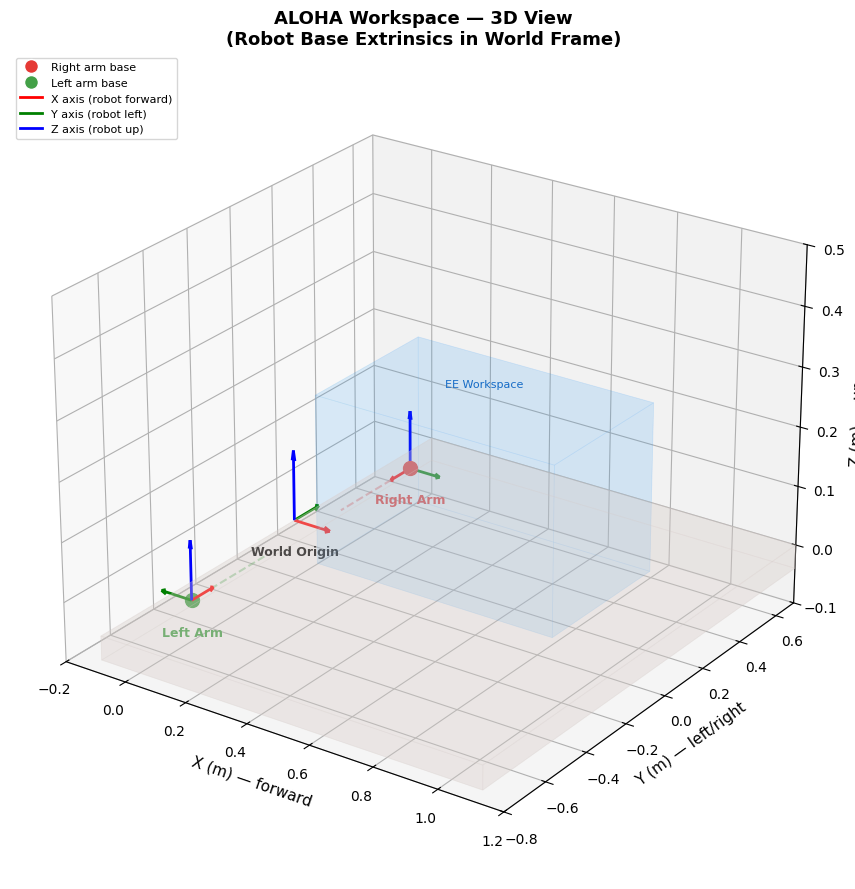

In [34]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.lines import Line2D

def draw_frame(ax, T, label, color, arrow_len=0.10):
    """Draw a coordinate frame from a 4x4 homogeneous transform."""
    origin = T[:3, 3]
    colors_axes = ['r', 'g', 'b']  # x=red, y=green, z=blue
    for i in range(3):
        direction = T[:3, i] * arrow_len
        ax.quiver(*origin, *direction, color=colors_axes[i], linewidth=2, arrow_length_ratio=0.15)
    ax.text(origin[0], origin[1], origin[2] - 0.06, label,
            fontsize=9, fontweight='bold', color=color, ha='center')

def draw_box(ax, center, size, color='#888888', alpha=0.15):
    """Draw a 3D rectangular box."""
    cx, cy, cz = center
    sx, sy, sz = size
    x = [cx - sx/2, cx + sx/2]
    y = [cy - sy/2, cy + sy/2]
    z = [cz - sz/2, cz + sz/2]
    verts = [
        [(x[0],y[0],z[0]), (x[1],y[0],z[0]), (x[1],y[1],z[0]), (x[0],y[1],z[0])],
        [(x[0],y[0],z[1]), (x[1],y[0],z[1]), (x[1],y[1],z[1]), (x[0],y[1],z[1])],
        [(x[0],y[0],z[0]), (x[1],y[0],z[0]), (x[1],y[0],z[1]), (x[0],y[0],z[1])],
        [(x[0],y[1],z[0]), (x[1],y[1],z[0]), (x[1],y[1],z[1]), (x[0],y[1],z[1])],
        [(x[0],y[0],z[0]), (x[0],y[1],z[0]), (x[0],y[1],z[1]), (x[0],y[0],z[1])],
        [(x[1],y[0],z[0]), (x[1],y[1],z[0]), (x[1],y[1],z[1]), (x[1],y[0],z[1])],
    ]
    poly = Poly3DCollection(verts, alpha=alpha, facecolor=color, edgecolor=color, linewidth=0.5)
    ax.add_collection3d(poly)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# --- World frame at origin ---
draw_frame(ax, np.eye(4), 'World Origin', 'black', arrow_len=0.12)

# --- Robot bases ---
draw_frame(ax, right, 'Right Arm', '#E53935')
ax.plot(*right[:3, 3], 'o', markersize=10, color='#E53935', zorder=5)

draw_frame(ax, left, 'Left Arm', '#43A047')
ax.plot(*left[:3, 3], 'o', markersize=10, color='#43A047', zorder=5)

# --- Table surface (approximate, at z~0) ---
draw_box(ax, center=(0.6, -0.1, -0.02), size=(1.2, 1.6, 0.04), color='#d7ccc8', alpha=0.2)

# --- EE workspace volume: x=[0.25,1.0], y=[-0.25,0.25], z=[0.02,0.30] ---
draw_box(ax, center=(0.625, 0.0, 0.16), size=(0.75, 0.50, 0.28), color='#2196F3', alpha=0.08)
ax.text(0.625, 0.0, 0.32, 'EE Workspace', fontsize=8, color='#1565C0', ha='center')

# --- Dashed lines showing robot forward directions ---
for mat, color in [(right, '#E53935'), (left, '#43A047')]:
    origin = mat[:3, 3]
    forward = mat[:3, 0] * 0.35
    end = origin + forward
    ax.plot([origin[0], end[0]], [origin[1], end[1]], [origin[2], end[2]],
            '--', color=color, alpha=0.4, linewidth=1.5)

# --- Formatting ---
ax.set_xlabel('X (m) — forward', fontsize=11)
ax.set_ylabel('Y (m) — left/right', fontsize=11)
ax.set_zlabel('Z (m) — up', fontsize=11)
ax.set_title('ALOHA Workspace — 3D View\n(Robot Base Extrinsics in World Frame)', fontsize=13, fontweight='bold')

ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.8, 0.7)
ax.set_zlim(-0.1, 0.5)
ax.view_init(elev=25, azim=-55)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E53935', markersize=10, label='Right arm base'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#43A047', markersize=10, label='Left arm base'),
    Line2D([0], [0], color='r', lw=2, label='X axis (robot forward)'),
    Line2D([0], [0], color='g', lw=2, label='Y axis (robot left)'),
    Line2D([0], [0], color='b', lw=2, label='Z axis (robot up)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
plt.tight_layout()